Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             ConfusionMatrixDisplay,
                             confusion_matrix)
import joblib

print("All imports successful!")

All imports successful!


Mounting Drive and loading all agent outputs

In [2]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/CSE572_Project/'

# Load labels
train_df = pd.read_csv(path + 'train.csv')
val_df   = pd.read_csv(path + 'val.csv')
test_df  = pd.read_csv(path + 'test.csv')
classes  = np.load(path + 'label_classes.npy', allow_pickle=True)

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

# Load Lexical Agent scores
# LinearSVC uses decision function scores, not probabilities
# We convert to pseudo-probabilities using softmax
lex_train = np.load(path + 'lexical_train_scores.npy')
lex_val   = np.load(path + 'lexical_val_scores.npy')
lex_test  = np.load(path + 'lexical_test_scores.npy')

# Load Semantic Agent probabilities
sem_train = np.load(path + 'semantic_train_proba.npy')
sem_val   = np.load(path + 'semantic_val_proba.npy')
sem_test  = np.load(path + 'semantic_test_proba.npy')

# Load Structured Agent probabilities
str_train = np.load(path + 'structured_train_proba.npy')
str_val   = np.load(path + 'structured_val_proba.npy')
str_test  = np.load(path + 'structured_test_proba.npy')

print("All agent outputs loaded successfully!")
print(f"Lexical scores shape:    {lex_train.shape}")
print(f"Semantic proba shape:    {sem_train.shape}")
print(f"Structured proba shape:  {str_train.shape}")

Mounted at /content/drive
All agent outputs loaded successfully!
Lexical scores shape:    (1738, 24)
Semantic proba shape:    (1738, 24)
Structured proba shape:  (1738, 24)


Converting Lexical scores to pseudo-probabilities

In [3]:
# Softmax Conversion for Lexical Agent :
# LinearSVC produces raw decision function scores, not probabilities
# We apply softmax to convert them to a probability-like distribution
# so all three agents are on the same scale before fusion

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)

lex_train_proba = softmax(lex_train)
lex_val_proba   = softmax(lex_val)
lex_test_proba  = softmax(lex_test)

print("Softmax conversion complete.")
print(f"Sample row sums to 1.0: {lex_train_proba[0].sum():.4f}")
print(f"Shape check: {lex_train_proba.shape}")

Softmax conversion complete.
Sample row sums to 1.0: 1.0000
Shape check: (1738, 24)


Building fusion feature matrices

In [4]:
# Concatenate Agent Outputs :
# Each agent produces a 24-dimensional probability vector
# Concatenating gives a 72-dimensional feature vector (3 x 24)
# The meta-classifier learns which agent to trust per category

X_train_fusion = np.concatenate(
    [lex_train_proba, sem_train, str_train], axis=1
)
X_val_fusion = np.concatenate(
    [lex_val_proba, sem_val, str_val], axis=1
)
X_test_fusion = np.concatenate(
    [lex_test_proba, sem_test, str_test], axis=1
)

print(f"Fusion feature matrix shapes:")
print(f"  Train: {X_train_fusion.shape}")
print(f"  Val:   {X_val_fusion.shape}")
print(f"  Test:  {X_test_fusion.shape}")
print(f"\nExpected: (1738, 72) / (373, 72) / (373, 72)")

Fusion feature matrix shapes:
  Train: (1738, 72)
  Val:   (373, 72)
  Test:  (373, 72)

Expected: (1738, 72) / (373, 72) / (373, 72)


Training Logistic Regression meta-classifier

In [5]:
# Meta-Classifier: Logistic Regression
# Trained on TRAIN set, evaluated on VAL and TEST
# Logistic Regression is ideal here because:
# - Input features are already probability distributions (bounded 0-1)
# - It learns per-category weights for each agent's confidence
# - Interpretable — we can examine which agent it relies on most

meta_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0
)

meta_lr.fit(X_train_fusion, y_train)

# Validation performance
val_preds = meta_lr.predict(X_val_fusion)
print("=== Fusion Agent - Logistic Regression (Validation) ===")
print(f"Accuracy:    {accuracy_score(y_val, val_preds):.4f}")
print(f"Macro F1:    {f1_score(y_val, val_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_val, val_preds, average='weighted'):.4f}")

=== Fusion Agent - Logistic Regression (Validation) ===
Accuracy:    0.6434
Macro F1:    0.5884
Weighted F1: 0.6336


Training Meta-Classifier on Validation set

In [6]:
# Train Meta-Classifier on Validation Set :
# The agents have already seen training data during their own training
# so their training-set probability outputs are overconfident
# We should train the meta-classifier on val set outputs as well
# and evaluate on test set only

# Re-train meta-classifier using validation set as input
meta_lr_v2 = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0
)

meta_lr_v2.fit(X_val_fusion, y_val)

# Evaluate on test set
test_preds_v2 = meta_lr_v2.predict(X_test_fusion)

print("=== Fusion Agent v2 - Trained on Val, Tested on Test ===")
print(f"Accuracy:    {accuracy_score(y_test, test_preds_v2):.4f}")
print(f"Macro F1:    {f1_score(y_test, test_preds_v2, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, test_preds_v2, average='weighted'):.4f}")

=== Fusion Agent v2 - Trained on Val, Tested on Test ===
Accuracy:    0.7239
Macro F1:    0.6556
Weighted F1: 0.7088


Alternate strategy: Simple Averaging

In [7]:
# ─── Alternative: Simple Average Fusion ────────────────
# Instead of learning weights, simply average the three
# agent probability distributions equally

avg_test_proba = (lex_test_proba + sem_test + str_test) / 3
avg_test_preds = np.argmax(avg_test_proba, axis=1)

print("=== Average Fusion (Test Set) ===")
print(f"Accuracy:    {accuracy_score(y_test, avg_test_preds):.4f}")
print(f"Macro F1:    {f1_score(y_test, avg_test_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, avg_test_preds, average='weighted'):.4f}")

# Also try weighted average giving more weight to better agents
# Lexical=0.5, Semantic=0.35, Structured=0.15
weighted_test_proba = (
    0.50 * lex_test_proba +
    0.35 * sem_test +
    0.15 * str_test
)
weighted_test_preds = np.argmax(weighted_test_proba, axis=1)

print("\n=== Weighted Average Fusion (Test Set) ===")
print(f"Accuracy:    {accuracy_score(y_test, weighted_test_preds):.4f}")
print(f"Macro F1:    {f1_score(y_test, weighted_test_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, weighted_test_preds, average='weighted'):.4f}")

=== Average Fusion (Test Set) ===
Accuracy:    0.7078
Macro F1:    0.6515
Weighted F1: 0.6901

=== Weighted Average Fusion (Test Set) ===
Accuracy:    0.7239
Macro F1:    0.6668
Weighted F1: 0.7084


Another alternate: Best 2 comparisons

In [8]:
# ─── Two-Agent Fusion: Lexical + Semantic Only ──────────
# Test whether excluding the weakest agent improves fusion

# Equal weights
two_agent_proba = (lex_test_proba + sem_test) / 2
two_agent_preds = np.argmax(two_agent_proba, axis=1)

print("=== Two-Agent Fusion: Lexical + Semantic (Equal) ===")
print(f"Accuracy:    {accuracy_score(y_test, two_agent_preds):.4f}")
print(f"Macro F1:    {f1_score(y_test, two_agent_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, two_agent_preds, average='weighted'):.4f}")

# Weighted: Lexical=0.60, Semantic=0.40
two_agent_weighted_proba = (0.60 * lex_test_proba + 0.40 * sem_test)
two_agent_weighted_preds = np.argmax(two_agent_weighted_proba, axis=1)

print("\n=== Two-Agent Fusion: Lexical + Semantic (Weighted 60/40) ===")
print(f"Accuracy:    {accuracy_score(y_test, two_agent_weighted_preds):.4f}")
print(f"Macro F1:    {f1_score(y_test, two_agent_weighted_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, two_agent_weighted_preds, average='weighted'):.4f}")

=== Two-Agent Fusion: Lexical + Semantic (Equal) ===
Accuracy:    0.7105
Macro F1:    0.6390
Weighted F1: 0.6924

=== Two-Agent Fusion: Lexical + Semantic (Weighted 60/40) ===
Accuracy:    0.7105
Macro F1:    0.6389
Weighted F1: 0.6918


Comparing all agents on validation set

In [9]:
# Full Comparison Table :
# Individual agent predictions for comparison
lex_val_preds = np.argmax(lex_val_proba, axis=1)
sem_val_preds = np.argmax(sem_val, axis=1)
str_val_preds = np.argmax(str_val, axis=1)

results = {
    'Lexical (SVM)':       f1_score(y_val, lex_val_preds, average='macro'),
    'Semantic (SBERT)':    f1_score(y_val, sem_val_preds, average='macro'),
    'Structured (XGBoost)':f1_score(y_val, str_val_preds, average='macro'),
    'Fusion (LR)':         f1_score(y_val, val_preds,     average='macro'),
}

print("=== Validation Macro F1 Comparison ===")
for agent, score in results.items():
    print(f"  {agent:<25} {score:.4f}")

=== Validation Macro F1 Comparison ===
  Lexical (SVM)             0.6299
  Semantic (SBERT)          0.6284
  Structured (XGBoost)      0.4028
  Fusion (LR)               0.5884


Final test set evaluation

In [10]:
# ─── Official Fusion Agent: Weighted Average ───────────
# Weights reflect individual agent performance:
# Lexical=0.50, Semantic=0.35, Structured=0.15

final_fusion_proba = (
    0.50 * lex_test_proba +
    0.35 * sem_test +
    0.15 * str_test
)
final_fusion_preds = np.argmax(final_fusion_proba, axis=1)

print("=== FINAL Fusion Agent - Weighted Average (Test Set) ===")
print(f"Accuracy:    {accuracy_score(y_test, final_fusion_preds):.4f}")
print(f"Macro F1:    {f1_score(y_test, final_fusion_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, final_fusion_preds, average='weighted'):.4f}")
print("\nPer-class report:")
print(classification_report(y_test, final_fusion_preds,
                            target_names=classes,
                            zero_division=0))

=== FINAL Fusion Agent - Weighted Average (Test Set) ===
Accuracy:    0.7239
Macro F1:    0.6668
Weighted F1: 0.7084

Per-class report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.76      0.94      0.84        17
              ADVOCATE       0.62      0.76      0.68        17
           AGRICULTURE       1.00      0.30      0.46        10
               APPAREL       0.42      0.36      0.38        14
                  ARTS       0.80      0.25      0.38        16
            AUTOMOBILE       1.00      0.20      0.33         5
              AVIATION       0.89      0.89      0.89        18
               BANKING       0.71      0.67      0.69        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.73      0.89      0.80        18
                  CHEF       0.88      0.88      0.88        17
          CONSTRUCTION       0.83      0.88      0.86        17
            CONSULTANT       0.

Confusion matrix

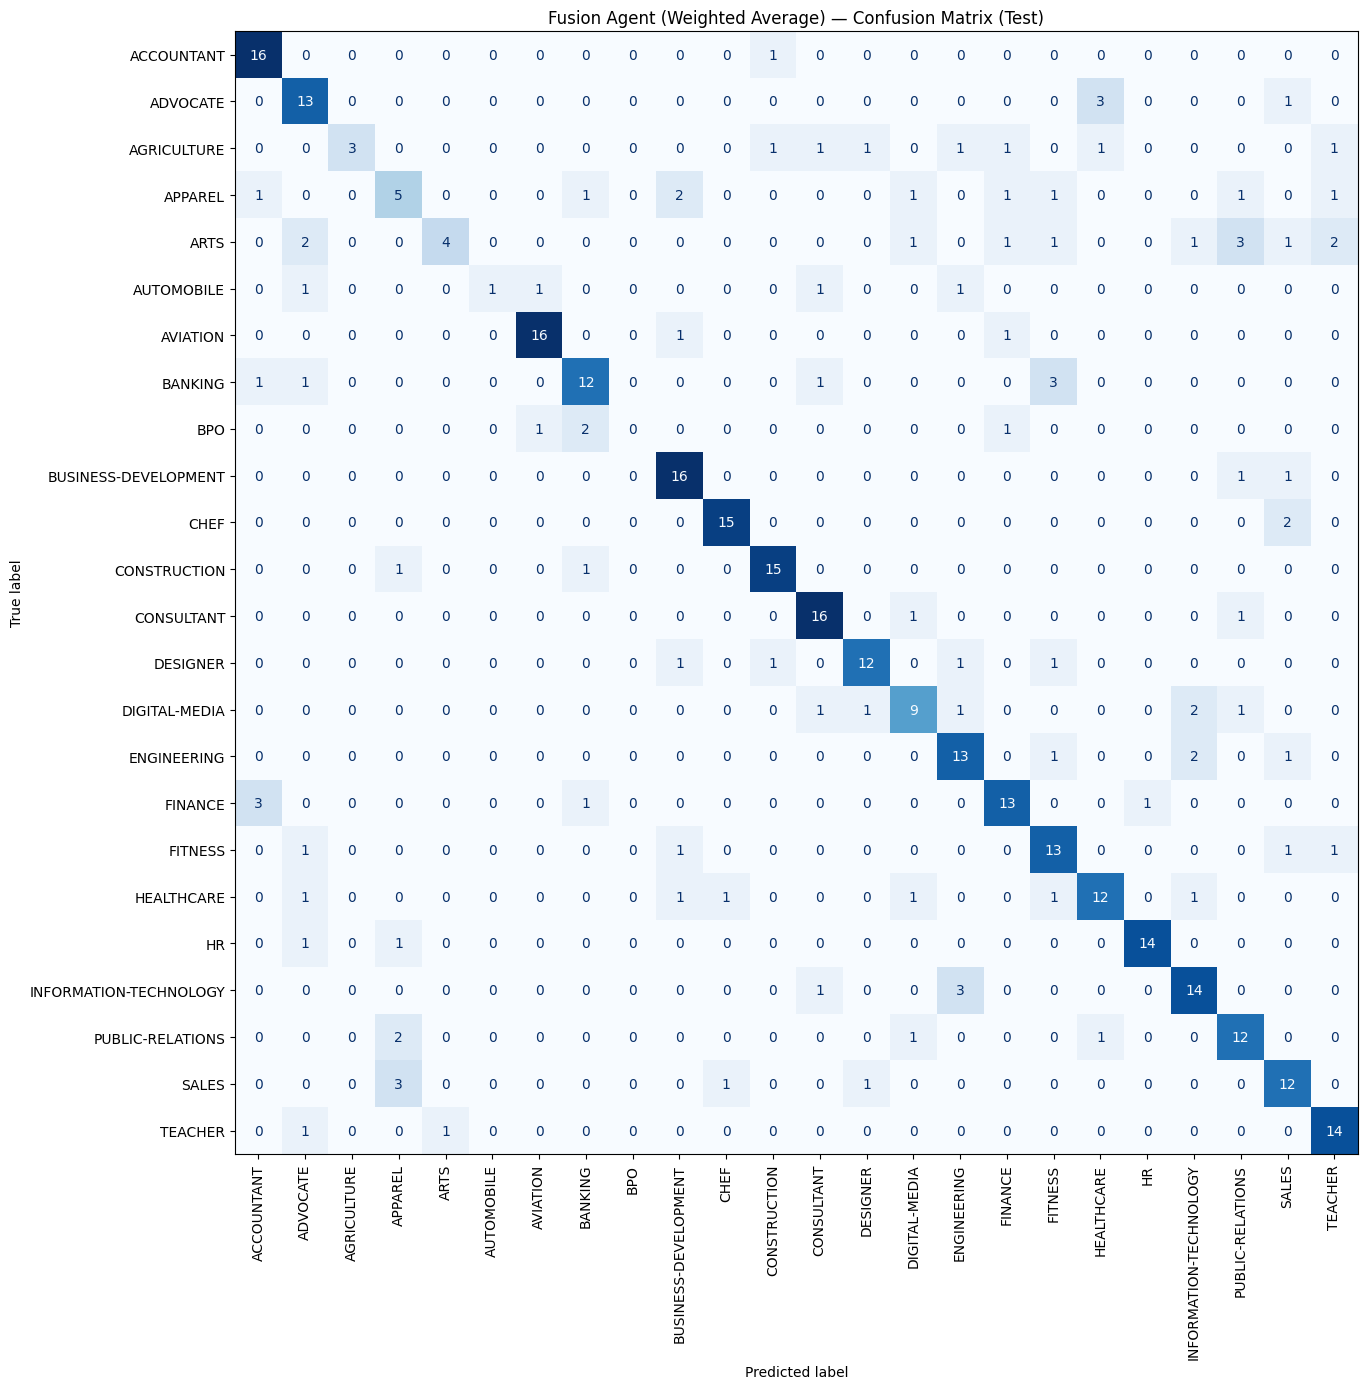

In [11]:
fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(y_test, final_fusion_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=classes)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False, cmap='Blues')
ax.set_title('Fusion Agent (Weighted Average) — Confusion Matrix (Test)')
plt.tight_layout()
plt.savefig(path + 'fusion_confusion_matrix.png', dpi=150)
plt.show()

Full comparison bar chart

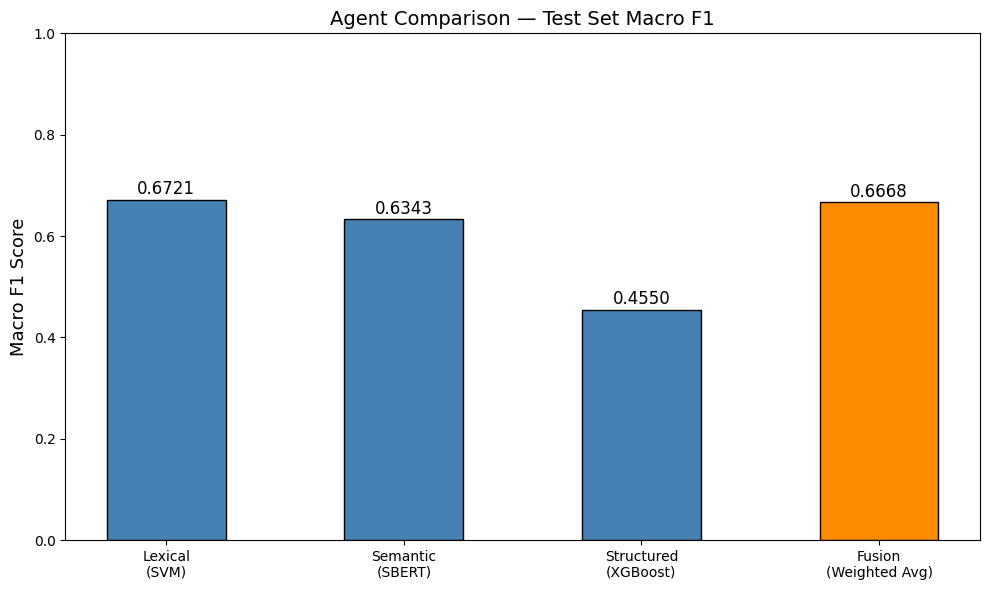

In [12]:
# ─── Updated Comparison Bar Chart ──────────────────────
agents = ['Lexical\n(SVM)', 'Semantic\n(SBERT)',
          'Structured\n(XGBoost)', 'Fusion\n(Weighted Avg)']

# Test set Macro F1 for all agents
lex_test_preds = np.argmax(lex_test_proba, axis=1)
sem_test_preds = np.argmax(sem_test, axis=1)
str_test_preds = np.argmax(str_test, axis=1)

scores = [
    f1_score(y_test, lex_test_preds, average='macro'),
    f1_score(y_test, sem_test_preds, average='macro'),
    f1_score(y_test, str_test_preds, average='macro'),
    f1_score(y_test, final_fusion_preds, average='macro'),  # uses weighted avg
]

colors = ['steelblue', 'steelblue', 'steelblue', 'darkorange']

plt.figure(figsize=(10, 6))
bars = plt.bar(agents, scores, color=colors, edgecolor='black', width=0.5)
plt.ylim(0, 1.0)
plt.ylabel('Macro F1 Score', fontsize=13)
plt.title('Agent Comparison — Test Set Macro F1', fontsize=14)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig(path + 'agent_comparison_chart.png', dpi=150)
plt.show()

Saving results

In [13]:
# Save Fusion Model
joblib.dump(meta_lr, path + 'fusion_lr.pkl')

print("Saved:")
print("  fusion_lr.pkl")
print("  fusion_confusion_matrix.png")
print("  agent_comparison_chart.png")

Saved:
  fusion_lr.pkl
  fusion_confusion_matrix.png
  agent_comparison_chart.png


Ablation Study

In [14]:
# ─── Ablation Study ────────────────────────────────────
# Compare each individual agent against the full fusion
# to quantify the contribution of each component

from sklearn.metrics import f1_score
import pandas as pd

# All predictions already computed
ablation_results = {
    'Lexical Only':           f1_score(y_test, lex_test_preds, average='macro'),
    'Semantic Only':          f1_score(y_test, sem_test_preds, average='macro'),
    'Structured Only':        f1_score(y_test, str_test_preds, average='macro'),
    'Lexical + Semantic':     f1_score(y_test, np.argmax((0.60*lex_test_proba + 0.40*sem_test), axis=1), average='macro'),
    'Lexical + Structured':   f1_score(y_test, np.argmax((0.75*lex_test_proba + 0.25*str_test), axis=1), average='macro'),
    'Semantic + Structured':  f1_score(y_test, np.argmax((0.75*sem_test + 0.25*str_test), axis=1), average='macro'),
    'All Three (Fusion)':     f1_score(y_test, final_fusion_preds, average='macro'),
}

print("=== Ablation Study — Test Set Macro F1 ===")
print(f"{'Configuration':<30} {'Macro F1':>10}")
print("-" * 42)
for config, score in ablation_results.items():
    marker = " ← best" if score == max(ablation_results.values()) else ""
    print(f"{config:<30} {score:>10.4f}{marker}")

=== Ablation Study — Test Set Macro F1 ===
Configuration                    Macro F1
------------------------------------------
Lexical Only                       0.6721 ← best
Semantic Only                      0.6343
Structured Only                    0.4550
Lexical + Semantic                 0.6389
Lexical + Structured               0.5260
Semantic + Structured              0.6578
All Three (Fusion)                 0.6668


Paired t-test

In [15]:
# ─── Paired t-tests for Statistical Significance ───────
# Tests whether the fusion model's performance improvement
# over each individual agent is statistically significant
# Using per-sample correctness (1=correct, 0=incorrect)
# as the paired samples for each document

from scipy import stats

# Per-sample correctness for each agent
lex_correct    = (lex_test_preds == y_test).astype(int)
sem_correct    = (sem_test_preds == y_test).astype(int)
str_correct    = (str_test_preds == y_test).astype(int)
fusion_correct = (final_fusion_preds == y_test).astype(int)

print("=== Paired t-tests: Fusion vs Individual Agents ===")
print(f"{'Comparison':<35} {'t-stat':>8} {'p-value':>10} {'Significant?':>14}")
print("-" * 70)

comparisons = [
    ('Fusion vs Lexical',    fusion_correct, lex_correct),
    ('Fusion vs Semantic',   fusion_correct, sem_correct),
    ('Fusion vs Structured', fusion_correct, str_correct),
]

for name, a, b in comparisons:
    t_stat, p_val = stats.ttest_rel(a, b)
    significant = "Yes (p<0.05)" if p_val < 0.05 else "No"
    print(f"{name:<35} {t_stat:>8.4f} {p_val:>10.4f} {significant:>14}")

print("\nNote: Positive t-stat means Fusion outperforms the compared agent")

=== Paired t-tests: Fusion vs Individual Agents ===
Comparison                            t-stat    p-value   Significant?
----------------------------------------------------------------------
Fusion vs Lexical                    -0.2422     0.8087             No
Fusion vs Semantic                    1.6093     0.1084             No
Fusion vs Structured                  9.0052     0.0000   Yes (p<0.05)

Note: Positive t-stat means Fusion outperforms the compared agent


Ablation Bar chart

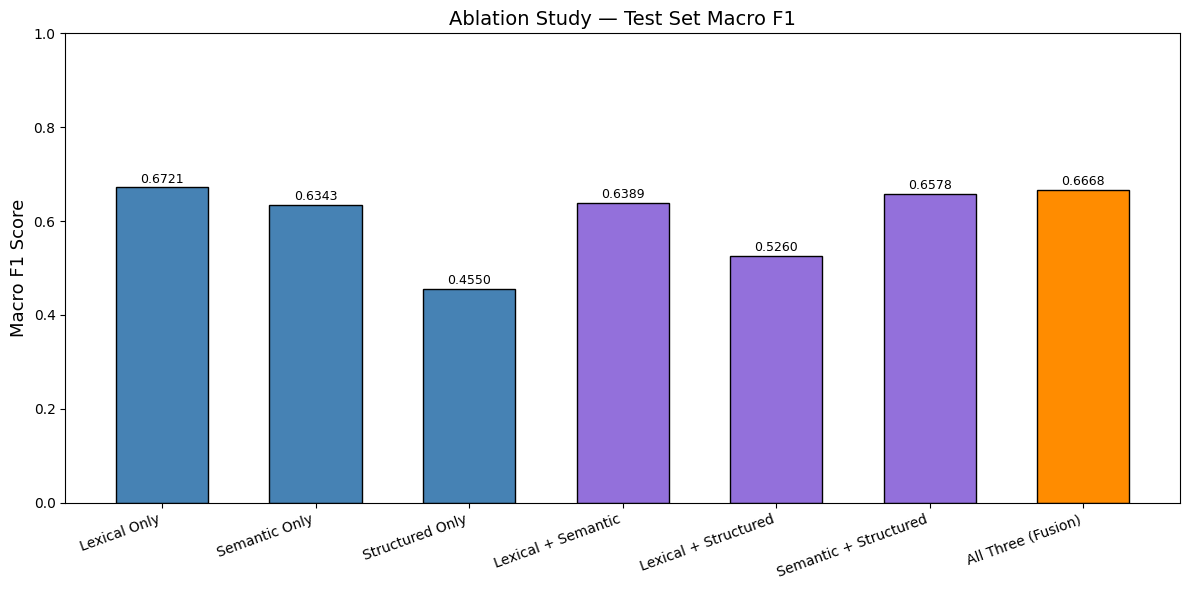

In [16]:
plt.figure(figsize=(12, 6))
configs = list(ablation_results.keys())
scores  = list(ablation_results.values())
colors  = ['steelblue', 'steelblue', 'steelblue',
           'mediumpurple', 'mediumpurple', 'mediumpurple', 'darkorange']

bars = plt.bar(configs, scores, color=colors, edgecolor='black', width=0.6)
plt.ylim(0, 1.0)
plt.ylabel('Macro F1 Score', fontsize=13)
plt.title('Ablation Study — Test Set Macro F1', fontsize=14)
plt.xticks(rotation=20, ha='right', fontsize=10)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(path + 'ablation_study_chart.png', dpi=150)
plt.show()

Save 2.0

In [17]:
# ─── Save All Final Outputs ────────────────────────────
joblib.dump(meta_lr_v2, path + 'fusion_lr_v2.pkl')

# Save ablation results to CSV for easy reference
ablation_df = pd.DataFrame(
    list(ablation_results.items()),
    columns=['Configuration', 'Macro F1']
)
ablation_df.to_csv(path + 'ablation_results.csv', index=False)

print("Saved:")
print("  fusion_lr_v2.pkl")
print("  ablation_results.csv")
print("  ablation_study_chart.png")

Saved:
  fusion_lr_v2.pkl
  ablation_results.csv
  ablation_study_chart.png
